# Project

## Loading the dataset

In [1]:
import glob
from typing import Tuple
import polars as pl
import os

In [2]:
DATA_ROOT = "data"

In [3]:
def get_labels_from_filename(filename: str) -> Tuple[str, str, bool]:
    if "Benign" in filename:
        return "Benign", "Benign", False

    if "ARP_Spoofing" in filename:
        return "ARP_Spoofing", "Spoofing", True

    if "Recon" in filename:
        category = "Recon"
        if "Recon-Ping_Sweep" in filename:
            return "Ping_Sweep", category, True
        if "Recon-VulScan" in filename:
            return "VulScan", category, True
        if "Recon-OS_Scan" in filename:
            return "OS_Scan", category, True
        if "Recon-Port_Scan" in filename:
            return "Port_Scan", category, True

    if "MQTT" in filename:
        category = "MQTT"
        if "MQTT-Malformed_Data" in filename:
            return "Malformed_Data", category, True
        if "MQTT-DoS-Connect_Flood" in filename:
            return "DoS_Connect_Flood", category, True
        if "MQTT-DDoS-Publish_Flood" in filename:
            return "DDoS_Publish_Flood", category, True
        if "MQTT-DoS-Publish_Flood" in filename:
            return "DoS_Publish Flood", category, True
        if "MQTT-DDoS-Connect_Flood" in filename:
            return "DDoS_Connect_Flood", category, True

    if "TCP_IP-DoS" in filename:
        category = "DoS"
        if "TCP_IP-DoS-TCP" in filename:
            return "DoS_TCP", category, True
        if "TCP_IP-DoS-ICMP" in filename:
            return "DoS_ICMP", category, True
        if "TCP_IP-DoS-SYN" in filename:
            return "DoS_SYN", category, True
        if "TCP_IP-DoS-UDP" in filename:
            return "DoS_UDP", category, True

    if "TCP_IP-DDoS" in filename:
        category = "DDoS"
        if "TCP_IP-DDoS-SYN" in filename:
            return "DDoS_SYN", category, True
        if "TCP_IP-DDoS-TCP" in filename:
            return "DDoS_TCP", category, True
        if "TCP_IP-DDoS-ICMP" in filename:
            return "DDoS_ICMP", category, True
        if "TCP_IP-DDoS-UDP" in filename:
            return "DDoS_UDP", category, True

    return "", "", False

In [4]:
def combine_dataset_files(root: str, save_name: str = "combined_dataset") -> None:
    path = os.path.join(root, "*", "*.csv")
    files = glob.glob(path, recursive=True)
    combined_dir = os.path.join(root, "combined")
    out_path = os.path.join(combined_dir, f"{save_name}.parquet")
    os.makedirs(combined_dir, exist_ok=True)

    frames = []
    with pl.StringCache():
        for file in files:
            name, category, attack = get_labels_from_filename(file)

            lf = pl.scan_csv(file)

            lf = lf.with_columns(
                [
                    pl.lit(name).alias("Name").cast(pl.Categorical),
                    pl.lit(category).alias("Category").cast(pl.Categorical),
                    pl.lit(attack).alias("Attack"),
                ]
            )

            frames.append(lf)

        combined_lf = pl.concat(frames)
        combined_lf.sink_parquet(out_path)

In [5]:
def load_dataset(save_name: str) -> pl.DataFrame:
    path = os.path.join(DATA_ROOT, "combined", f"{save_name}.parquet")
    if not os.path.exists(path):
        combine_dataset_files(DATA_ROOT, save_name)
    df = pl.read_parquet(path)
    return df

In [6]:
df = load_dataset("combined_dataset").with_columns(
    pl.col(pl.Float64).cast(pl.Float32)
)  # reducing memory usage

## Exploratory Data Analysis

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [8]:
sns.set_theme(style="darkgrid", context="paper", palette="bright")

In [9]:
def plot_attack_counts(data):
    attack_counts = data.group_by("Name").len().sort("len", descending=False)
    attack_counts = attack_counts.to_pandas()
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x="Name", y="len", data=attack_counts, ax=ax)
    ax.set_title("Distribution of Attack Names (Entire Dataset)")
    ax.set_xlabel("Attack Name")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment="right",
        rotation_mode="anchor",
    )

    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()

/tmp/ipykernel_47708/4110133150.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


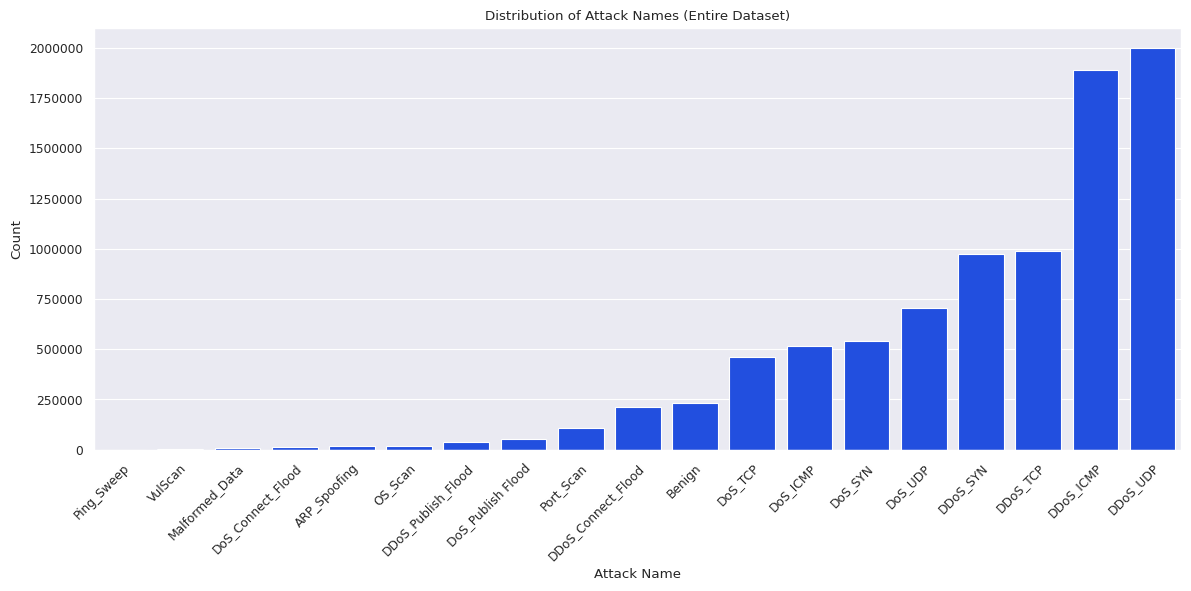

In [10]:
plot_attack_counts(df)

In [11]:
def plot_ddos_dos_bar(data):
    ddos_dos_counts = (
        data.filter(pl.col("Category").is_in(["DDoS", "DoS"]))
        .group_by("Category")
        .len()
        .sort("len", descending=False)
    )
    data = ddos_dos_counts.to_pandas()
    data.columns = ["Attack Type", "Count"]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x="Attack Type", y="Count", data=data, ax=ax)
    ax.set_title("Distribution of DDoS and DoS Attacks (Entire Dataset)")
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment="right",
        rotation_mode="anchor",
    )

    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()

/tmp/ipykernel_47708/4247166012.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


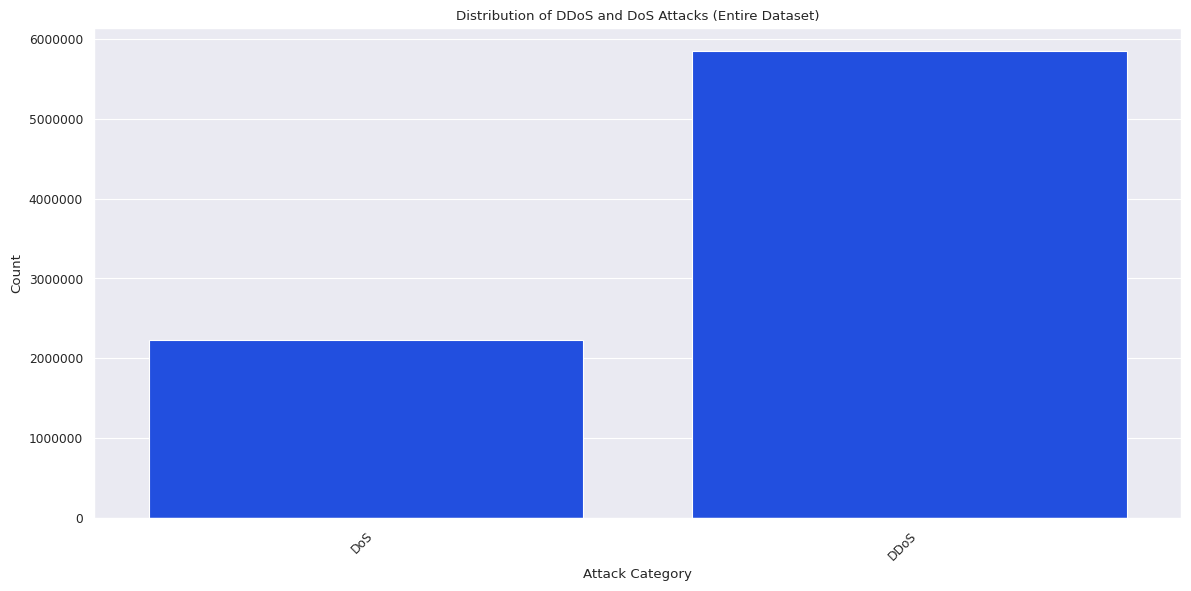

In [12]:
plot_ddos_dos_bar(df)

In [13]:
def plot_categories_no_ddos_dos(data):
    included_categories = ["MQTT", "Spoofing", "Recon", "Benign"]
    data = (
        data.filter(pl.col("Category").is_in(included_categories))
        .group_by("Category")
        .len()
        .sort("len", descending=False)
    ).to_pandas()

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x="Category", y="len", data=data, ax=ax)
    ax.set_title(
        "Distribution of Attack Categories (Excluding DDoS and DoS) (Entire Dataset)"
    )
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment="right",
        rotation_mode="anchor",
    )

    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()

/tmp/ipykernel_47708/2544595696.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


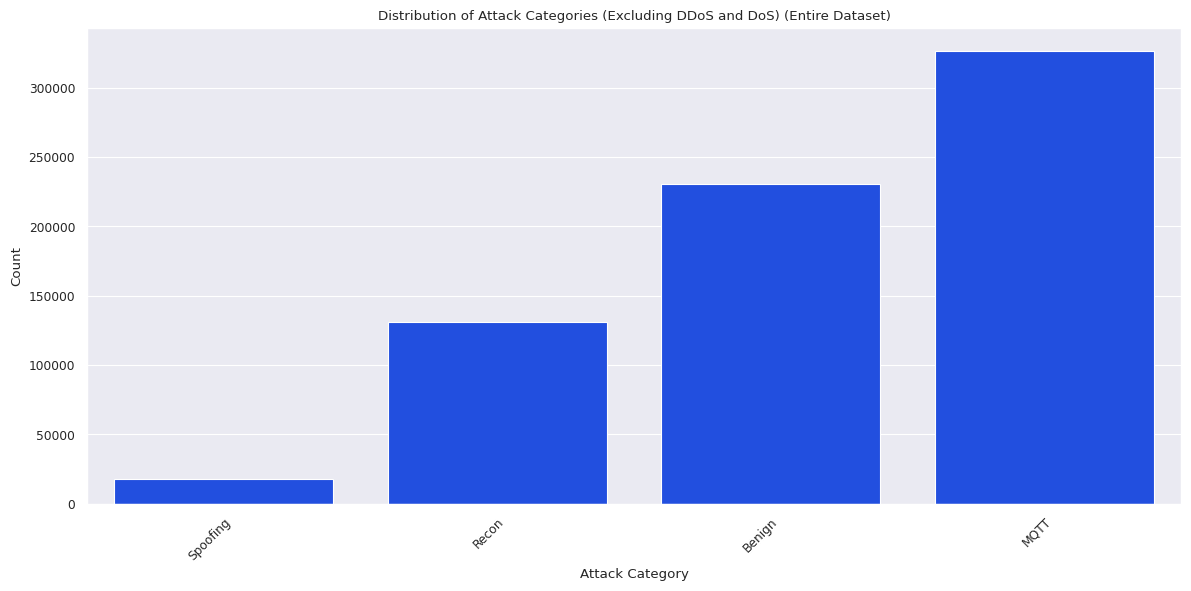

In [14]:
plot_categories_no_ddos_dos(df)

In [15]:
def plot_all_attack_categories_bar(data):
    data = data.group_by("Category").len().sort("len", descending=False).to_pandas()
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(x="Category", y="len", data=data, ax=ax)
    ax.set_title("Distribution of Attack Categories (Entire Dataset)")
    ax.set_xlabel("Attack Category")
    ax.set_ylabel("Count")

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=45,
        horizontalalignment="right",
        rotation_mode="anchor",
    )

    plt.ticklabel_format(style="plain", axis="y")
    plt.tight_layout()

/tmp/ipykernel_47708/3849087223.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


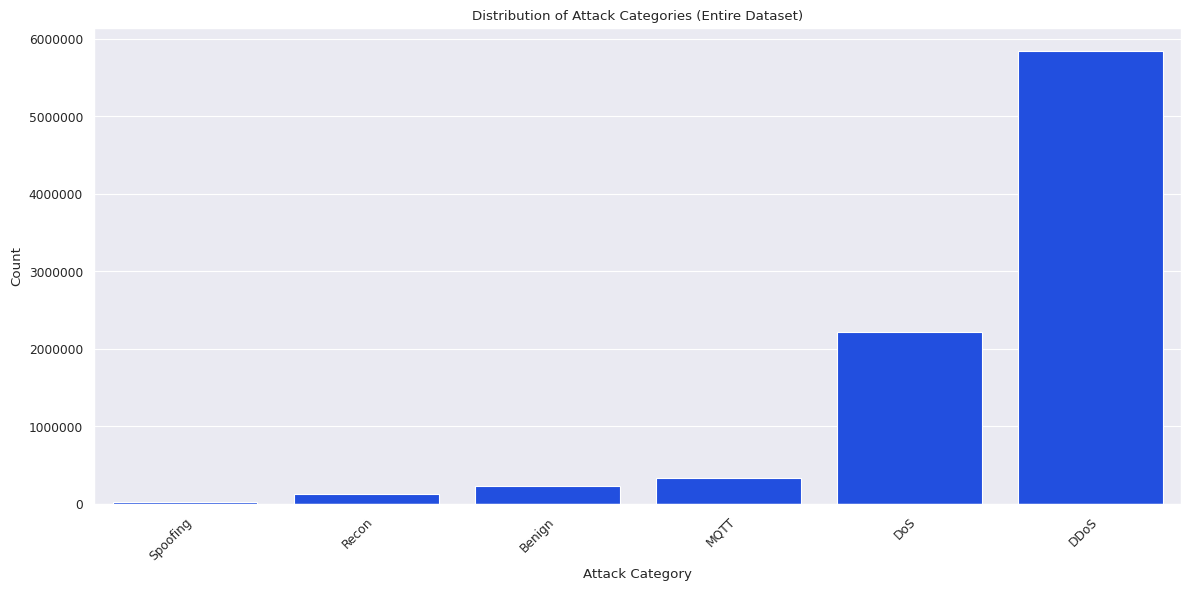

In [16]:
plot_all_attack_categories_bar(df)

In [17]:
def plot_attack_benign_pie(data):
    attack_counts = data.group_by("Attack").len().sort("len", descending=False)
    attack_counts = attack_counts.to_pandas()
    attack_counts.columns = ["Attack", "Count"]

    attack_counts = attack_counts.set_index("Attack")["Count"]
    total_count = attack_counts.sum()
    percentages = (attack_counts / total_count) * 100
    slices = attack_counts.values
    labels = attack_counts.index

    colours = sns.color_palette("hls", len(labels))

    fig, ax = plt.subplots()
    ax.set_title("Comparison between Benign and Attack Data (Entire Dataset)")
    plt.pie(
        slices,
        colors=colours,
        wedgeprops=dict(edgecolor="black", linewidth=1),
        textprops=dict(color="white", fontsize=10),
        startangle=90,
    )

    legend_labels = [
        f"{label} ({percentage:.2f}%)" for label, percentage in zip(labels, percentages)
    ]
    ax.legend(
        legend_labels,
        title="Malicious Traffic?",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.gca().set_aspect("equal")

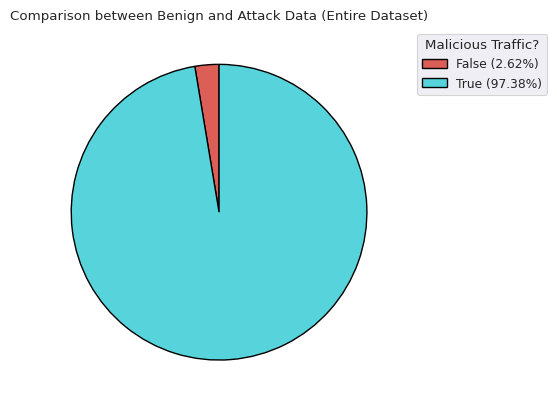

In [18]:
plot_attack_benign_pie(df)

In [19]:
def plot_breakdown_pie(data, title):
    target_column = "Category"
    attack_counts = data.group_by(target_column).len().sort(target_column)
    attack_counts = attack_counts.to_pandas()
    attack_counts.columns = [target_column, "Count"]

    attack_counts = attack_counts.set_index(target_column)["Count"]
    total_count = attack_counts.sum()
    percentages = (attack_counts / total_count) * 100
    slices = attack_counts.values
    labels = attack_counts.index

    fig, ax = plt.subplots()
    ax.set_title(title)
    colours = sns.color_palette("tab20", len(labels))
    plt.pie(
        slices,
        wedgeprops=dict(edgecolor="black", linewidth=1),
        textprops=dict(color="white", fontsize=10),
        startangle=90,
        colors=colours,
    )

    legend_labels = [
        f"{label} ({percentage:.2f}%)" for label, percentage in zip(labels, percentages)
    ]
    ax.legend(
        legend_labels,
        title=f"Attack {target_column}",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
    )

    plt.gca().set_aspect("equal")

In [20]:
def plot_correlation_heatmap(data):
    numeric_data = data.select(
        pl.exclude("Attack", "Category", "Name").name.map(lambda name: name.lower())
    )

    std_devs = numeric_data.select(pl.all().std())
    zer_var_cols = [col for col in std_devs.columns if std_devs[col][0] == 0]
    numeric_data = numeric_data.drop(zer_var_cols)

    corr = numeric_data.corr()
    corr_labels = corr.columns
    corr = corr.to_numpy()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(15, len(corr_labels) // 2))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        square=True,
        ax=ax,
        mask=mask,
        cbar_kws={"label": "Correlation Coefficient", "shrink": 0.5, "aspect": 30},
        xticklabels=corr_labels,
        yticklabels=corr_labels,
    )

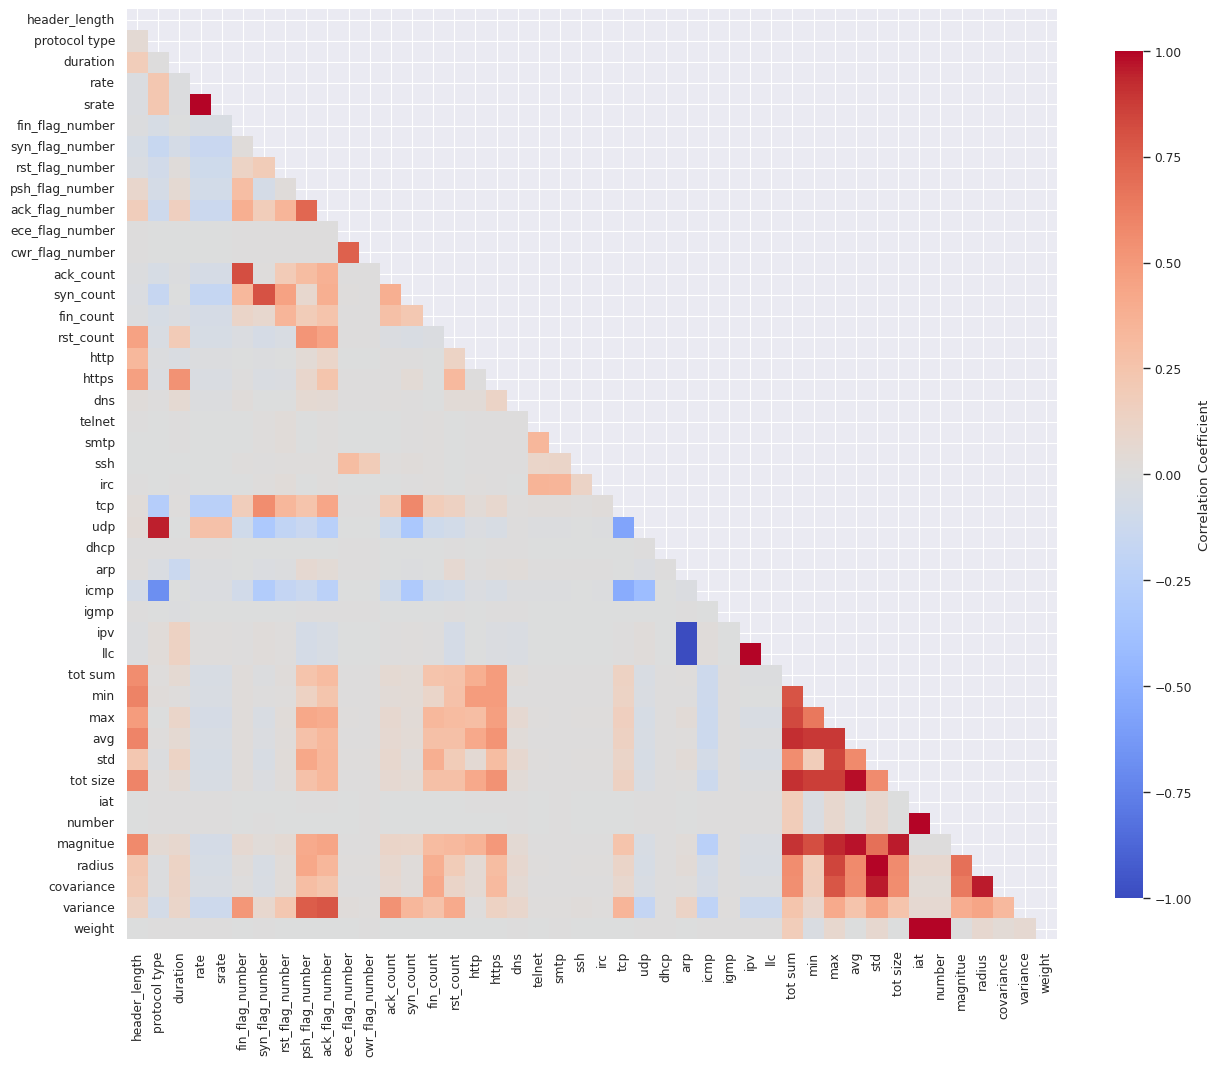

In [21]:
plot_correlation_heatmap(df)

## Preprocessing

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
df = df.to_pandas()
df = df[df["Category"] != "Spoofing"].copy()  # Discarding spoofing data
df = df.reset_index(drop=True)
X = df.drop(columns=["Name", "Attack", "Category"])
y = df["Category"]

In [24]:
del df

### Splitting Data into Subsets

In [25]:
train_percent = 0.8
val_percent = 0.1
test_percent = 0.1

In [26]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=test_percent, random_state=42, stratify=y
)

val_adjusted_size = val_percent / (train_percent + val_percent)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=val_adjusted_size,
    random_state=42,
    stratify=y_train_val,
)

In [27]:
del X_train_val, y_train_val

In [28]:
print(f"Train {len(X_train)/len(X):.0%} ({len(X_train)})")
print(f"Validation {len(X_val)/len(X):.0%} ({len(X_val)})")
print(f"Test {len(X_test)/len(X):.0%} ({len(X_test)})")

Train 80% (7005776)
Validation 10% (875723)
Test 10% (875723)


### Sampling Techniques

In [29]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

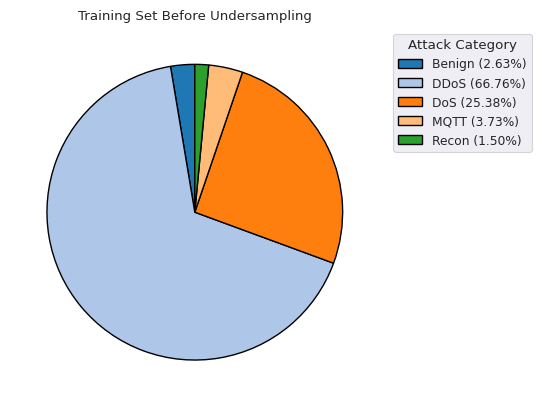

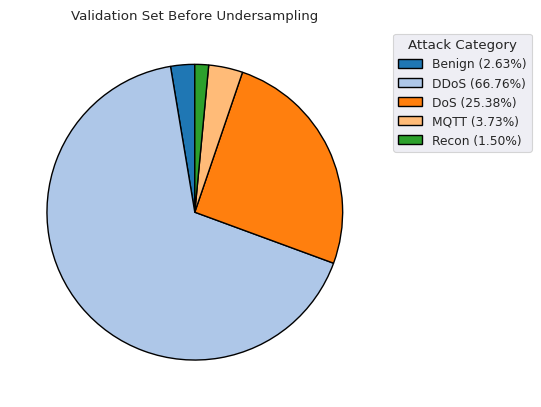

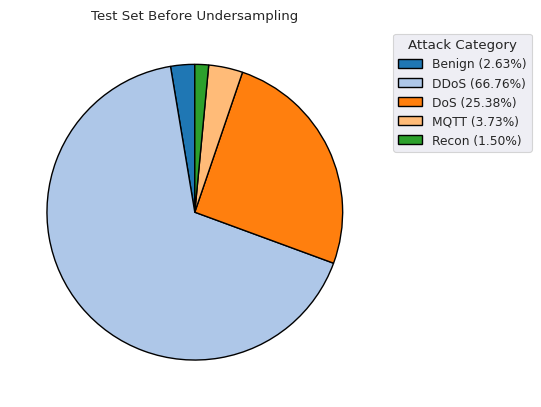

In [30]:
plot_breakdown_pie(
    pl.DataFrame({"Category": y_train}), "Training Set Before Undersampling"
)
plot_breakdown_pie(
    pl.DataFrame({"Category": y_val}), "Validation Set Before Undersampling"
)
plot_breakdown_pie(pl.DataFrame({"Category": y_test}), "Test Set Before Undersampling")

In [31]:
undersample_strategy = {
    "DDoS": 2_500_000,
}
oversample_strategy = {
    "Benign": 1_200_000,
    "MQTT": 800_000,
    "Recon": 600_000,
}

In [32]:
pipeline = Pipeline(
    steps=[
        ("over", SMOTE(sampling_strategy=oversample_strategy, random_state=42)),
        ("under", RandomUnderSampler(sampling_strategy=undersample_strategy)),
    ]
)

In [33]:
X_train, y_train = pipeline.fit_resample(X_train, y_train)

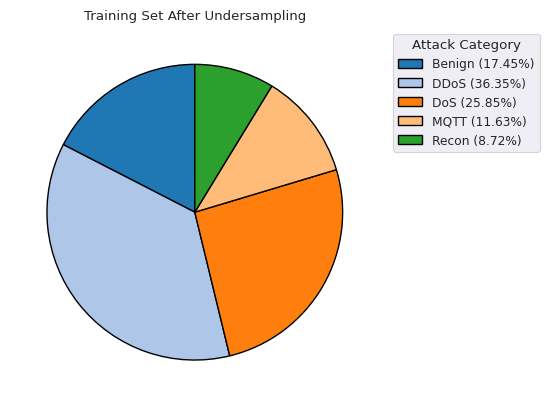

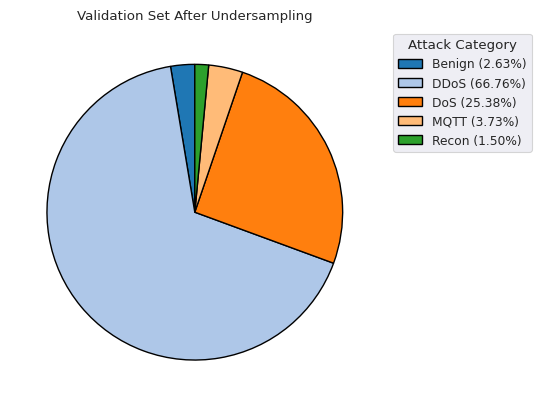

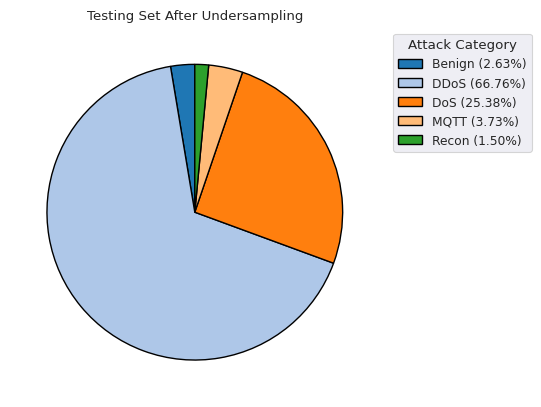

In [34]:
plot_breakdown_pie(
    pl.DataFrame({"Category": y_train}), "Training Set After Undersampling"
)
plot_breakdown_pie(
    pl.DataFrame({"Category": y_val}), "Validation Set After Undersampling"
)
plot_breakdown_pie(
    pl.DataFrame({"Category": y_test}), "Testing Set After Undersampling"
)

## Scaling and Labelling Data

In [35]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [36]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.transform(y_val)
y_test = encoder.transform(y_test)

In [37]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [38]:
del X_train, X_val

In [39]:
print(f"Training shape: {X_train_scaled.shape}")
print(f"Validation shape: {X_val_scaled.shape}")
print(f"Testing shape: {X_test_scaled.shape}")

Training shape: (6877763, 45)
Validation shape: (875723, 45)
Testing shape: (875723, 45)


## Model Design

In [40]:
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

2026-02-25 19:18:47.561351: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-25 19:18:48.239065: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-25 19:18:51.230202: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [41]:
def build_dnn(input_dimensions, output_dimension=5):
    model = Sequential(
        [
            Input(shape=(input_dimensions[1],)),
            Dense(256, activation="relu", kernel_regularizer=l2(1e-5)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(128, activation="relu", kernel_regularizer=l2(1e-5)),
            BatchNormalization(),
            Dropout(0.2),
            Dense(64, activation="relu", kernel_regularizer=l2(1e-5)),
            Dense(output_dimension, activation="softmax"),
        ]
    )

    optimizer = Adam(learning_rate=3e-4)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [42]:
model = build_dnn(X_train_scaled.shape, 5)
model.summary()

2026-02-25 19:18:51.899907: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        11,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,789 (214.02 KB)

 Trainable params: 54,021 (211.02 KB)

 Non-trainable params: 768 (3.00 KB)

## Model Training

In [43]:
from sklearn.utils import class_weight

In [44]:
classes = np.unique(y_train)
weights = class_weight.compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

In [45]:
BATCH_SIZE = 2048
EPOCHS = 75

In [46]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, min_lr=1e-5),
    ],
    class_weight=class_weights,
)

Epoch 1/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 69s 20ms/step - accuracy: 0.7596 - loss: 0.3115 - val_accuracy: 0.6842 - val_loss: 0.5487 - learning_rate: 3.0000e-04
Epoch 2/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 70s 21ms/step - accuracy: 0.7845 - loss: 0.2721 - val_accuracy: 0.7085 - val_loss: 0.5270 - learning_rate: 3.0000e-04
Epoch 3/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 73s 22ms/step - accuracy: 0.7870 - loss: 0.2649 - val_accuracy: 0.7182 - val_loss: 0.5186 - learning_rate: 3.0000e-04
Epoch 4/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 77s 23ms/step - accuracy: 0.7896 - loss: 0.2610 - val_accuracy: 0.7258 - val_loss: 0.5069 - learning_rate: 3.0000e-04
Epoch 5/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 80s 24ms/step - accuracy: 0.7939 - loss: 0.2566 - val_accuracy: 0.7356 - val_loss: 0.5045 - learning_rate: 3.0000e-04
Epoch 6/75
3359/3359 ━━━━━━━━━━━━━━━━━━━━ 77s 23ms/step - accuracy: 0.7975 - loss: 0.2538 - val_accuracy: 0.6508 - val_loss: 0.5062 - learning_rate: 3.0000e-04
Epoch 7/75
3359/3359 ━━━━━━━━━━━━━━━━━━━

In [47]:
model.save("model.keras")

## Model Evalutation

In [48]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

In [49]:
def plot_accuracy_and_loss(history):

    train_loss = history["loss"]
    val_loss = history["val_loss"]
    train_acc = history["accuracy"]
    val_acc = history["val_accuracy"]

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Accuracy
    ax[0].plot(train_acc, label="Training Accuracy")
    ax[0].plot(val_acc, label="Validation Accuracy")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Accuracy")
    ax[0].legend()

    # Loss
    ax[1].plot(train_loss, label="Training Loss")
    ax[1].plot(val_loss, label="Validation Loss")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].legend()

    plt.show()

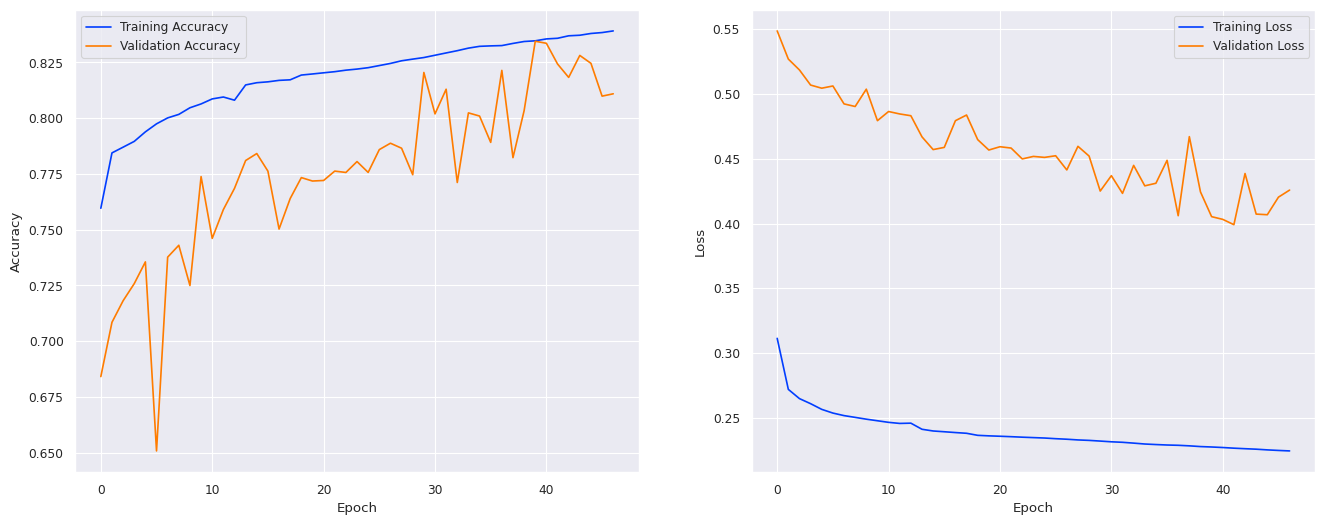

In [50]:
plot_accuracy_and_loss(history.history)

In [51]:
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(1, 2, figsize=(20, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax[0],
        xticklabels=classes,
        yticklabels=classes,
    )
    ax[0].set_title("Confusion Matrix (Counts)")
    ax[0].set_ylabel("True Label")
    ax[0].set_xlabel("Predicted Label")

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Greens",
        ax=ax[1],
        xticklabels=classes,
        yticklabels=classes,
    )
    ax[1].set_title("Confusion Matrix (Normalized)")
    ax[1].set_ylabel("True Label")
    ax[1].set_xlabel("Predicted Label")

    plt.tight_layout()
    plt.show()

In [52]:
y_pred_probs = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

27367/27367 ━━━━━━━━━━━━━━━━━━━━ 65s 2ms/step


[[ 22666      1      0    124    243]
 [     3 519156  65497      5      2]
 [     5  86215 135995      4      2]
 [   239      0      6  32402     18]
 [   515      1      1      9  12614]]


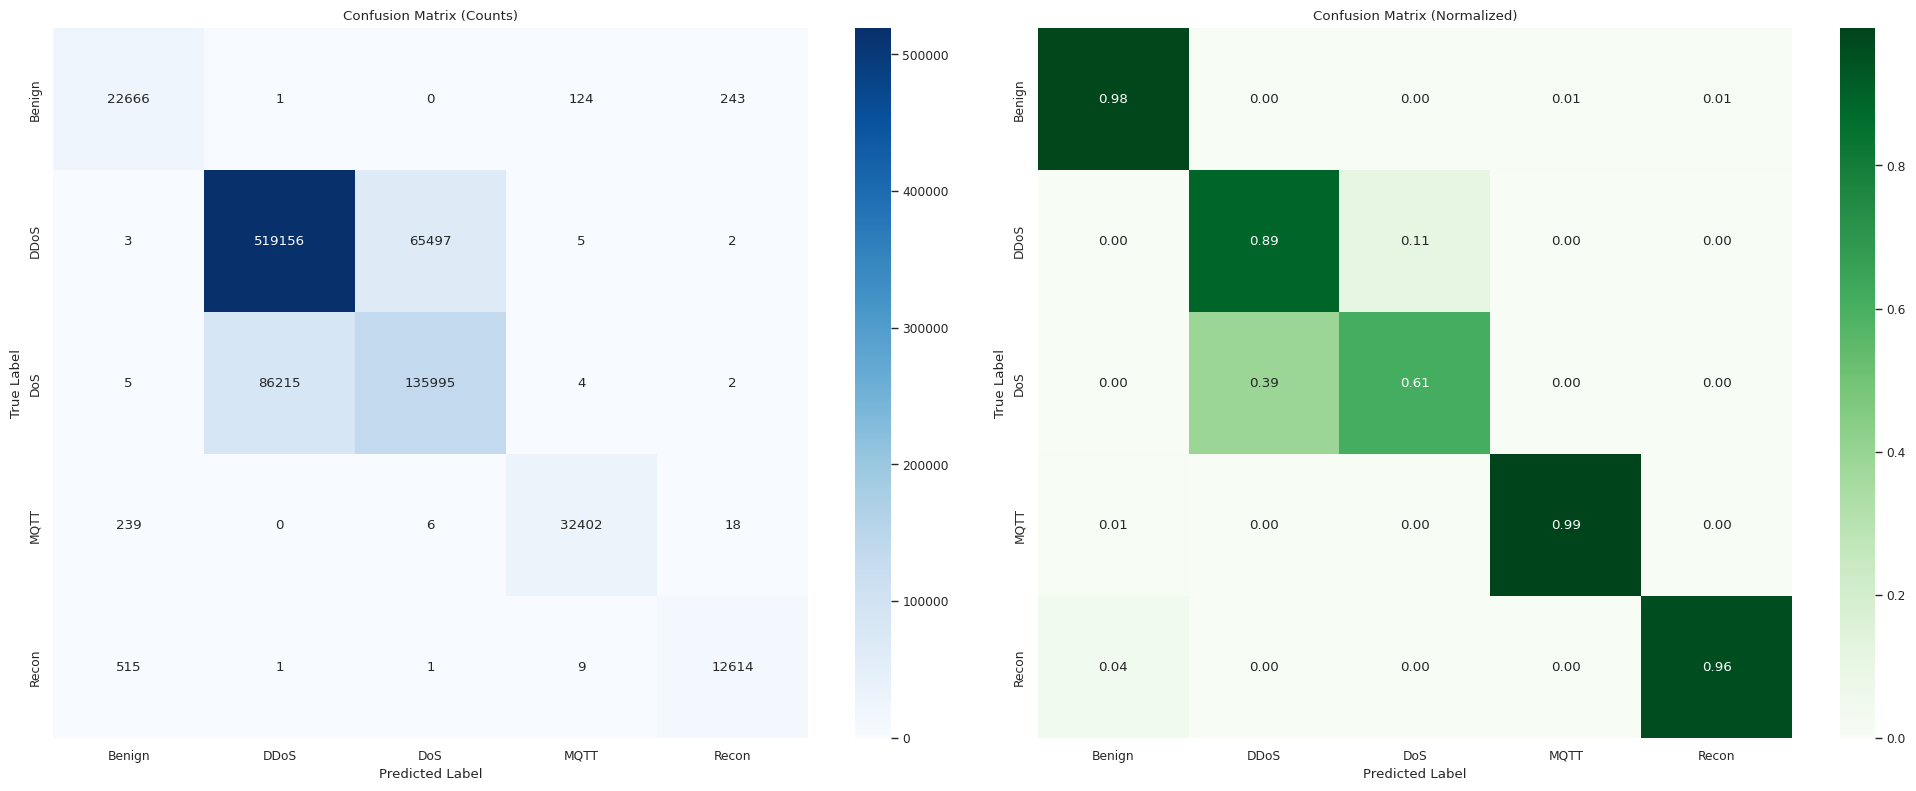

In [53]:
plot_confusion_matrix(y_test, y_pred_classes, encoder.classes_)

In [54]:
print(
    classification_report(
        y_test, y_pred_classes, digits=4, target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

      Benign     0.9675    0.9840    0.9757     23034
        DDoS     0.8576    0.8880    0.8725    584663
         DoS     0.6749    0.6120    0.6419    222221
        MQTT     0.9956    0.9919    0.9938     32665
       Recon     0.9794    0.9600    0.9696     13140

    accuracy                         0.8254    875723
   macro avg     0.8950    0.8872    0.8907    875723
weighted avg     0.8211    0.8254    0.8227    875723



In [55]:
f1_score(y_test, y_pred_classes, average="macro")

0.8906963677146866

In [56]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test accuracy: {accuracy:.4f}")

27367/27367 ━━━━━━━━━━━━━━━━━━━━ 60s 2ms/step - accuracy: 0.8254 - loss: 0.3981
Test accuracy: 0.8254


## Explainability

In [40]:
import shap
from tensorflow.keras.models import load_model

model = load_model("model.keras")
shap.initjs()

/home/sssspppuud/Desktop/Project/Code/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-26 11:00:33.566117: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-26 11:00:34.230804: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-26 11:00:38.001544: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may se

In [41]:
X_train_scaled.columns

Index(['Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate',
       'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
       'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count',
       'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP',
       'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max',
       'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius',
       'Covariance', 'Variance', 'Weight'],
      dtype='object')

In [43]:
_, X_sample_unscaled, _, y_sample = train_test_split(
    X_test, y_test, test_size=500, stratify=y_test, random_state=42
)
_, X_sample_scaled, _, y_sample = train_test_split(
    X_test_scaled, y_test, test_size=500, stratify=y_test, random_state=42
)
X_sample_array = X_sample_scaled.values

In [44]:
del X_test

In [45]:
background = shap.sample(X_train_scaled,500)
class_labels = encoder.classes_

### SHAP

In [46]:
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(X_sample_array)


/home/sssspppuud/Desktop/Project/Code/.venv/lib/python3.12/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/home/sssspppuud/Desktop/Project/Code/.venv/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(500, 45))']
  warnings.warn(msg)
/home/sssspppuud/Desktop/Project/Code/.venv/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(1000, 45))']
  warnings.warn(msg)


In [47]:
print(f"Model output shape: {model.output_shape}")
print(f"Number of SHAP arrays: {len(shap_values)}")
print(f"Number of labels: {len(encoder.classes_)}")

Model output shape: (None, 5)
Number of SHAP arrays: 500
Number of labels: 5


SHAP summary for class: Benign


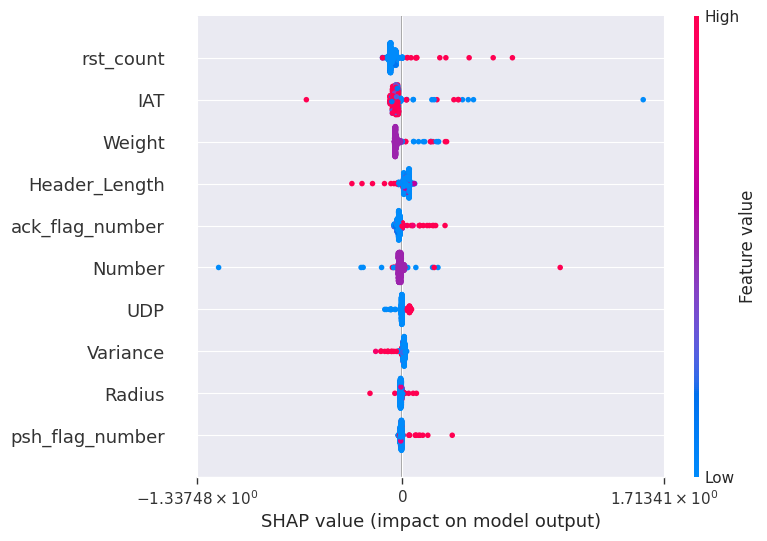

SHAP summary for class: DDoS


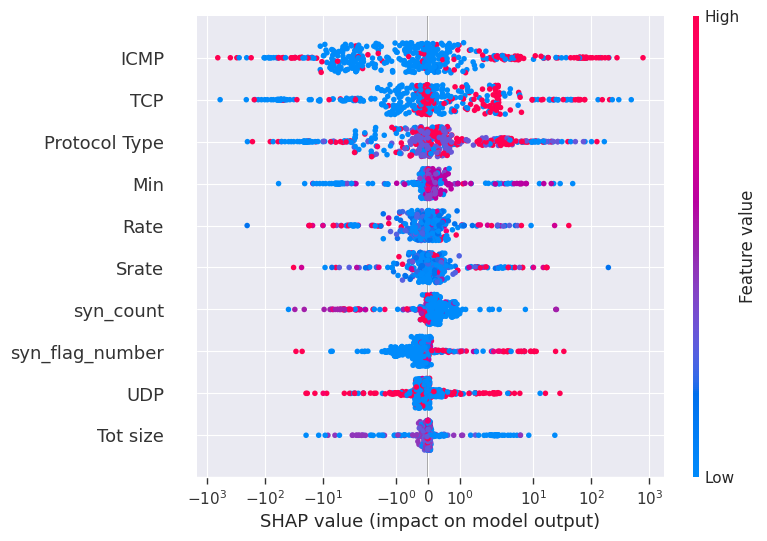

SHAP summary for class: DoS


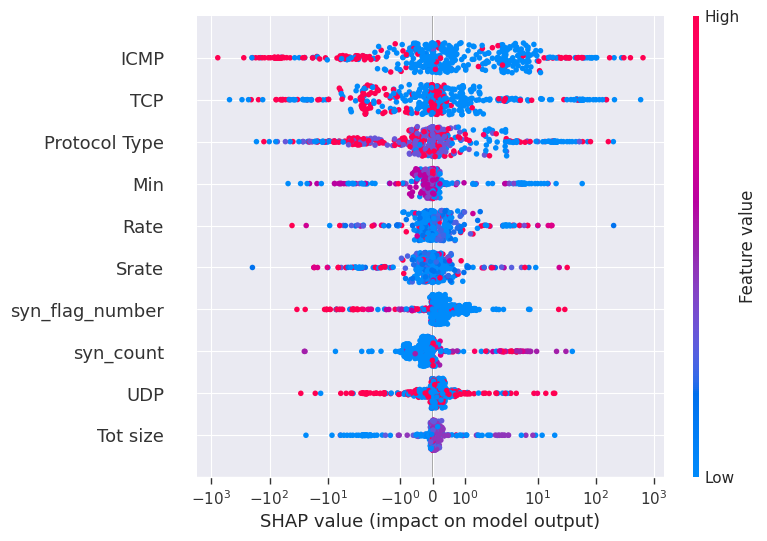

SHAP summary for class: MQTT


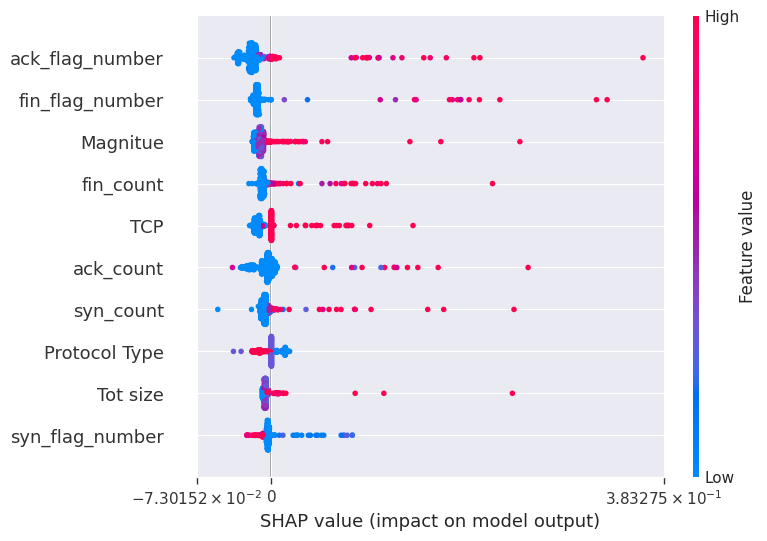

SHAP summary for class: Recon


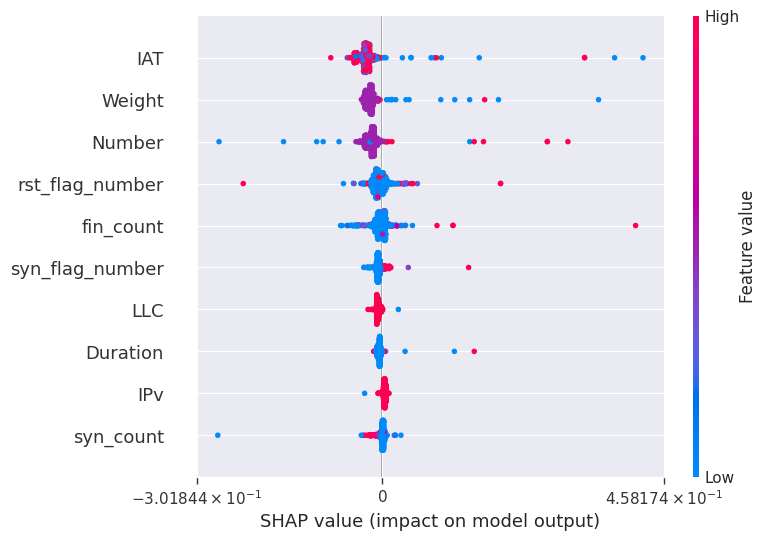

In [56]:
for i, class_name in enumerate(encoder.classes_):
    print(f"SHAP summary for class: {class_name}")
    
    shap.summary_plot(
        shap_values[:, :, i],
        features = X_sample_unscaled,
        show=True,
        feature_names = X_sample_scaled.columns,
        max_display= 10,
        use_log_scale=True
    )